In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion
import scipy.sparse as sp
from skimage import measure
from matplotlib import cm, colors

def Dx2_3d(N, dx):
    N3 = N**3
    D = sp.eye(N3, k = -2*N) - 2*sp.eye(N3) + sp.eye(N3, k = 2*N)
    return D / dx**2

def Dy2_3d(N, dy):
    N3 = N**3
    D = sp.eye(N3, k = -N) - 2*sp.eye(N3) + sp.eye(N3, k = N)
    D = D.tolil()
    i = N*(N-1)
    while (i < N3 - N*(N-1)):
        j = 0
        while (j<N):
            D[i+j,i+j+N] = 0
            D[i+j+N,i+j] = 0
            j += 1
        i += j + N*(N-1)
    D = D.tocsr()
    return D / dy**2

def Dz2_3d(N, dz):
    N3 = N**3
    D = sp.eye(N3, k = -1) - 2*sp.eye(N3) + sp.eye(N3, k = 1)
    D = D.tolil()
    for i in range(N-1, N3-1, N):
        D[i,i+1] = 0
        D[i+1,i] = 0
    D = D.tocsr()
    return D / dz**2

C:\Users\lucas\AppData\Local\Temp\ipykernel_5020\1103703888.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0, L_malha/5, 2*L_malha/5, 3*L_malha/5, 4*L_malha/5, L_malha])
C:\Users\lucas\AppData\Local\Temp\ipykernel_5020\1103703888.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, C_malha/5, 2*C_malha/5, 3*C_malha/5, 4*C_malha/5, C_malha])
C:\Users\lucas\AppData\Local\Temp\ipykernel_5020\1103703888.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_zticklabels([0, H_malha/5, 2*H_malha/5, 3*H_malha/5, 4*H_malha/5, H_malha])


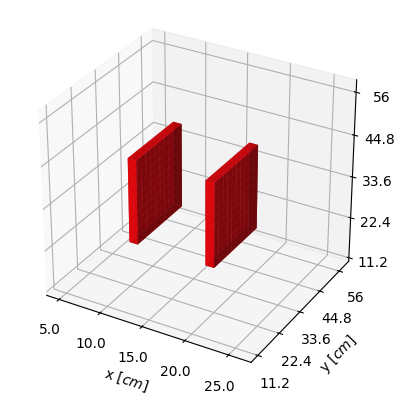

In [92]:
##Definindo a forma física do capacitor:

# Dimensões do capacitor:

L_placa = 1.5 #cm
C_placa = 28 #cm
H_placa = 28 #cm

d_placas = 10 #cm

# Dimensões da malha:

L_malha = 2.5*d_placas
C_malha = 2*C_placa
H_malha = 2*H_placa

## Construindo os operadores lineares:

N = 21 

dx = L_malha / N
dy = C_malha / N
dz = H_malha / N

Dx2 = Dx2_3d(N, dx)
Dy2 = Dy2_3d(N, dy)
Dz2 = Dz2_3d(N, dz)

Lp = Dx2 + Dy2 + Dz2

## Construindo o dispositivo:

B = np.zeros((N,N,N))

x = (L_malha - d_placas)/2 - L_placa
y = (C_malha - C_placa)/2
z = (H_malha - H_placa)/2

ix1_0 = int(x/dx)
ix1 = int((x + L_placa)/dx)

ix2_0 = int((x+L_placa + d_placas)/dx)
ix2 = int((x+2*L_placa+d_placas)/dx)

iy_0 = int(y/dy)
iy = int((y+C_placa)/dy)

iz_0 = int(z/dz)
iz = int((z+H_placa)/dz)

B[ix1_0:ix1, iy_0:iy, iz_0:iz] = 1
B[ix2_0:ix2, iy_0:iy, iz_0:iz] = 1

# Visualizando a estrutura:

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

mask = B != 0
shell = mask ^ binary_erosion(mask)

ax.voxels(shell, facecolors=[0,0,1,0.1])
ax.voxels(B != 0, facecolors=[1,0,0,0.8])
#ax.set_title(r'Forma física do capacitor')
ax.set_box_aspect([2.5*L_malha, C_malha, H_malha]) #Ajusta o tamanho da caixa, ampliando o eixo x
ax.set_xticklabels([0, L_malha/5, 2*L_malha/5, 3*L_malha/5, 4*L_malha/5, L_malha])
ax.set_yticklabels([0, C_malha/5, 2*C_malha/5, 3*C_malha/5, 4*C_malha/5, C_malha])
ax.set_zticklabels([0, H_malha/5, 2*H_malha/5, 3*H_malha/5, 4*H_malha/5, H_malha])
ax.set_xlabel(r'x [$cm$]')
ax.set_ylabel(r'y [$cm$]')

plt.show()

## Resolvendo a equação de Laplace ##

In [93]:
while True:
        T = input("Qual placa esta aterrada? 1 para a da esquerda e 2 para a da direita: ")
        if((T == '1') or (T == '2')):
            break
        else:
            print("Opção inválida! Selecione 1 ou 2")

V0 = np.abs(float(input("Informe a tensão entre as placas em Volts: "))) # abs para evitar problemas com valores negativos.

if T == 1:
    B[ix1_0:ix1, iy_0:iy, iz_0:iz] = V0 + 1e-9
    B[ix2_0:ix2, iy_0:iy, iz_0:iz] = 1e-9
else:
    B[ix1_0:ix1, iy_0:iy, iz_0:iz] = 1e-9
    B[ix2_0:ix2, iy_0:iy, iz_0:iz] = V0 + 1e-9

b = B.reshape(-1)

idx = np.where(b != 0)[0]

Lp = Lp.tolil()
for i in idx:
    Lp[i,:] = 0
    Lp[i,i] = 1
Lp = Lp.tocsr()

V = sp.linalg.spsolve(Lp, b) # Resolução da equação
V = V.reshape((N,N,N))


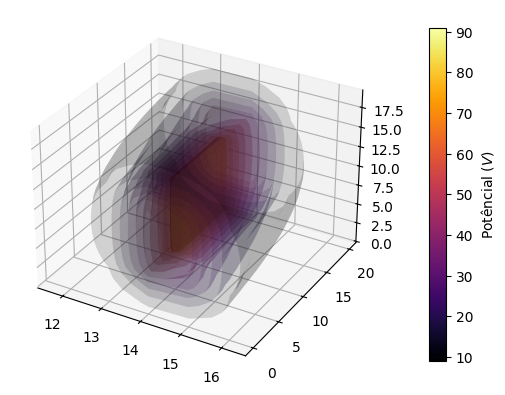

Tensão entre as placas: 100 V.


In [98]:
##Mostrando as superfícies equipotênciais

x_array = np.linspace(0,L_malha,N)
y_array = np.linspace(0,C_malha,N)
z_array = np.linspace(0,H_malha,N)
X,Y,Z = np.meshgrid(x_array, y_array, z_array, indexing = 'ij')

N_superficies = 10
levels = np.linspace(np.min(V),np.max(V),N_superficies + 2)[1:-1]

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
norm = colors.Normalize(vmin = np.min(levels), vmax = np.max(levels))
cmap = cm.inferno

i = 0
for lvl in levels:
    if (lvl == levels[-1]):
        a = 1
    else:
        a = 0.15
    verts, faces, _, _ = measure.marching_cubes(V, level = lvl)
    ax.plot_trisurf(
        verts[:,0], verts[:,1], faces, verts[:,2],
        alpha = a,
        color = cmap(i)
    )
    i += 1 / N_superficies

sm = cm.ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([])
fig.colorbar(sm, ax = ax, shrink = 0.9, aspect = 20, pad = 0.1, label = r'Potêncial ($V$)')

plt.show()

print("\33[1mTensão entre as placas: %d V.\33[0m" %(V0))